In [1]:
!pip install xgboost
!pip install shap


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

"""
Testing should only be performed on the real dataset.
"""

real_train_X = pd.read_csv("/work/datasets/preprocessed/real_X_train.csv")
real_test_X = pd.read_csv("/work/datasets/preprocessed/real_X_test.csv")
real_train_y = pd.read_csv("/work/datasets/preprocessed/real_y_train.csv")
real_test_y = pd.read_csv("/work/datasets/preprocessed/real_y_test.csv")


synth_train_X = pd.read_csv("/work/datasets/preprocessed/synthetic_X_train.csv")
synth_test_X = pd.read_csv("/work/datasets/preprocessed/synthetic_X_test.csv")
synth_train_y = pd.read_csv("/work/datasets/preprocessed/synthetic_y_train.csv")
synth_test_y = pd.read_csv("/work/datasets/preprocessed/synthetic_y_test.csv")


DATASETS = {
    "real": {
        "X": {
            "train": real_train_X,
            "test": real_test_X
        },
        "y": {
            "train": real_train_y,
            "test": real_test_y
        }
    },
    "synthetic": {
        "X": {
            "train": synth_train_X,
            "test": real_test_X
        },
        "y": {
            "train": synth_train_y,
            "test": real_test_y
        }
    },
    "concatenated": {
        "X": {
            "train": pd.concat([real_train_X, synth_train_X]),
            "test": real_test_X
        },
        "y": {
            "train": pd.concat([real_train_y, synth_train_y]),
            "test": real_test_y
        }
    }
}

DATASETS

{'real': {'X': {'train':            Age  CAEC_Frequently  CAEC_Sometimes  CAEC_no  CALC_Frequently  \
   0    -0.522124              0.0             0.0      0.0              0.0   
   1    -0.533953              0.0             1.0      0.0              0.0   
   2    -0.222692              0.0             1.0      0.0              0.0   
   3    -0.390041              1.0             0.0      0.0              0.0   
   4     0.265136              0.0             1.0      0.0              0.0   
   ...        ...              ...             ...      ...              ...   
   1683  1.257405              0.0             1.0      0.0              0.0   
   1684 -0.206889              0.0             1.0      0.0              0.0   
   1685 -0.208489              0.0             1.0      0.0              0.0   
   1686 -0.206889              0.0             1.0      0.0              0.0   
   1687 -0.679742              0.0             1.0      0.0              0.0   
   
         CALC_

In [3]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
from time import time

def train_evaluate_classifiers(X_train, y_train, X_test, y_test, random_state=42):
    """
    Train and evaluate multiple classifiers using 5-fold cross validation
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features
    y_train : pd.Series
        Training labels
    X_test : pd.DataFrame
        Test features
    y_test : pd.Series
        Test labels
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict : Dictionary containing results for each classifier
    """
    
    # Initialize LabelEncoder and transform labels
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train.values.ravel())
    y_test_encoded = le.transform(y_test.values.ravel())
    
    # Define classifiers
    classifiers = {
        'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=random_state),
        'GradientBoosting': GradientBoostingClassifier(random_state=random_state),
        'SVM': SVC(random_state=random_state),
        'DecisionTree': DecisionTreeClassifier(random_state=random_state),
        'NaiveBayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_jobs=-1),
        'XGBoost': XGBClassifier(n_jobs=-1, random_state=random_state),
    }
    
    # Define scoring metrics
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    }
    
    results = {}
    
    for name, clf in classifiers.items():
        print(f"Training {name} classifier...")
        # Start timing
        start_time = time()
        
        # Ensure X_train and X_test have the same columns
        common_columns = list(set(X_train.columns) & set(X_test.columns))
        X_train_filtered = X_train[common_columns]
        X_test_filtered = X_test[common_columns]
        
        # Perform cross-validation
        cv_results = cross_validate(
            clf,
            X_train_filtered,
            y_train_encoded,  # Use encoded labels
            cv=5,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=True
        )
        
        # Fit on full training data and evaluate on test set
        clf_fit = clf.fit(X_train_filtered, y_train_encoded)  # Use encoded labels
        test_pred_encoded = clf.predict(X_test_filtered)
        
        # Convert predictions back to original labels for evaluation
        test_pred = le.inverse_transform(test_pred_encoded)
        
        test_scores = precision_recall_fscore_support(y_test.values.ravel(), test_pred, average='macro')
        test_accuracy = accuracy_score(y_test.values.ravel(), test_pred)
        
        # Store results
        results[name] = {
            'cv_accuracy': np.mean(cv_results['test_accuracy']),
            'cv_accuracy_std': np.std(cv_results['test_accuracy']),
            'cv_precision': np.mean(cv_results['test_precision_macro']),
            'cv_recall': np.mean(cv_results['test_recall_macro']),
            'cv_f1': np.mean(cv_results['test_f1_macro']),
            'test_accuracy': test_accuracy,
            'test_precision': test_scores[0],
            'test_recall': test_scores[1],
            'test_f1': test_scores[2],
            'training_time': time() - start_time,
            'fitted_model': clf_fit
        }
    
    return results

RESULTS = {}

# Test the function on both real and synthetic datasets
for dataset_name, dataset in DATASETS.items():
    print(f"\nEvaluating on {dataset_name} dataset:")
    
    # Prepare data
    X_train = dataset['X']['train']
    y_train = dataset['y']['train']
    X_test = dataset['X']['test']
    y_test = dataset['y']['test']

    print("Dataset sizes:")
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_test: {y_test.shape}")
    
    """
    # For synthetic dataset, use only the first 423 test samples to match real dataset

    if dataset_name == 'synthetic':
        X_test = X_test.iloc[:423]
        y_test = y_test.iloc[:423]
    """

    # Train and evaluate
    results = train_evaluate_classifiers(X_train, y_train, X_test, y_test)
    
    # Store results
    RESULTS[dataset_name] = results

    # Print results
    for clf_name, metrics in results.items():
        print(f"\n{clf_name}:")
        print(f"CV Accuracy: {metrics['cv_accuracy']:.3f} (±{metrics['cv_accuracy_std']:.3f})")
        print(f"Test Accuracy: {metrics['test_accuracy']:.3f}")
        print(f"Test F1-Score: {metrics['test_f1']:.3f}")
        print(f"Training Time: {metrics['training_time']:.2f} seconds")


Evaluating on real dataset:
Dataset sizes:
X_train: (1688, 21)
y_train: (1688, 1)
X_test: (423, 21)
y_test: (423, 1)
Training RandomForest classifier...
Training GradientBoosting classifier...
Training SVM classifier...
Training DecisionTree classifier...
Training NaiveBayes classifier...
Training KNN classifier...
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Training XGBoost classifier...

RandomForest:
CV Accuracy: 0.855 (±0.010)
Test Accuracy: 0.858
Test F1-Score: 0.859
Training Time: 5.87 seconds

GradientBoosting:
CV Accuracy: 0.801 (±0.024)
Test Accuracy: 0.792
Test F1-Score: 0.787
Training Time: 10.83 seconds

SVM:
CV Accuracy: 0.693 (±0.019)
Test Accuracy: 0.693
Test F1-Score: 0.672
Training Time: 1.40 seconds

DecisionTree:
CV

In [4]:
# Modified approach to handle the results structure with markdown tables
markdown_text = "# Classifier Evaluation Results\n\n"

# make a markdown table from the results
for dataset_name, results in RESULTS.items():
    markdown_text += f"## {dataset_name.capitalize()} Dataset\n\n"
    
    # Create table header
    markdown_text += "| Classifier | CV Accuracy | Test Accuracy | Test F1-Score | Training Time (s) |\n"
    markdown_text += "|------------|-------------|---------------|---------------|------------------|\n"
    
    # Order by f1-score
    results_ord = {k: v for k, v in sorted(results.items(), key=lambda item: item[1]['test_f1'], reverse=True)}

    # Add each classifier's results as a row
    for clf_name, metrics in results_ord.items():
        markdown_text += f"| {clf_name} | {metrics['cv_accuracy']:.3f} (±{metrics['cv_accuracy_std']:.3f}) | "
        markdown_text += f"{metrics['test_accuracy']:.3f} | {metrics['test_f1']:.3f} | {metrics['training_time']:.2f} |\n"
    
    markdown_text += "\n"  # Add space between dataset tables

# Write to file
with open('classification_results.md', 'w') as f:
    f.write(markdown_text)

print("Results have been written to classification_results.md")

Results have been written to classification_results.md


> explainable ai for the fitted models

I'll analyze the fitted models using various explainable AI techniques. Let's start with feature importance analysis for the best performing models. First, let's look at the Random Forest model from the real dataset since it had the best performance.

/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


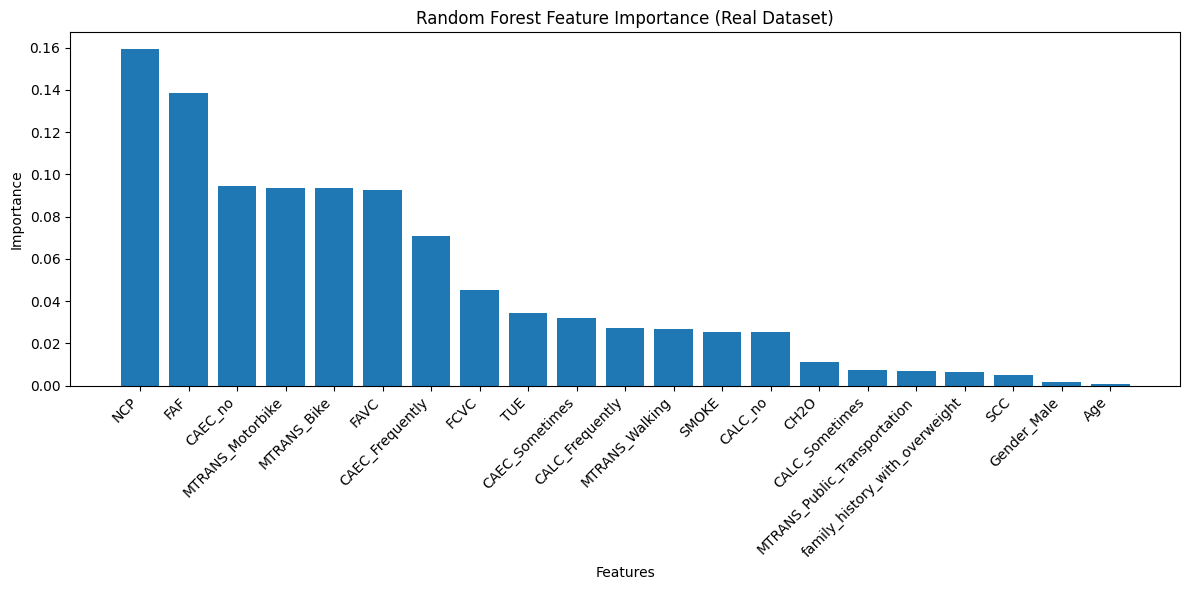


Top 5 Most Important Features:
             feature  importance
16               NCP    0.159241
8                FAF    0.138698
3            CAEC_no    0.094372
13  MTRANS_Motorbike    0.093660
12       MTRANS_Bike    0.093464


In [5]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the best model (Random Forest) from real dataset
rf_model = RESULTS['real']['RandomForest']['fitted_model']
feature_names = real_train_X.columns

# Feature importance plot
plt.figure(figsize=(12, 6))
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
})
importances = importances.sort_values('importance', ascending=False)

plt.bar(range(len(importances)), importances['importance'])
plt.xticks(range(len(importances)), importances['feature'], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance (Real Dataset)')
plt.tight_layout()
plt.show()

# Print top 5 most important features
print("\nTop 5 Most Important Features:")
print(importances.head())

<Figure size 1200x800 with 0 Axes>

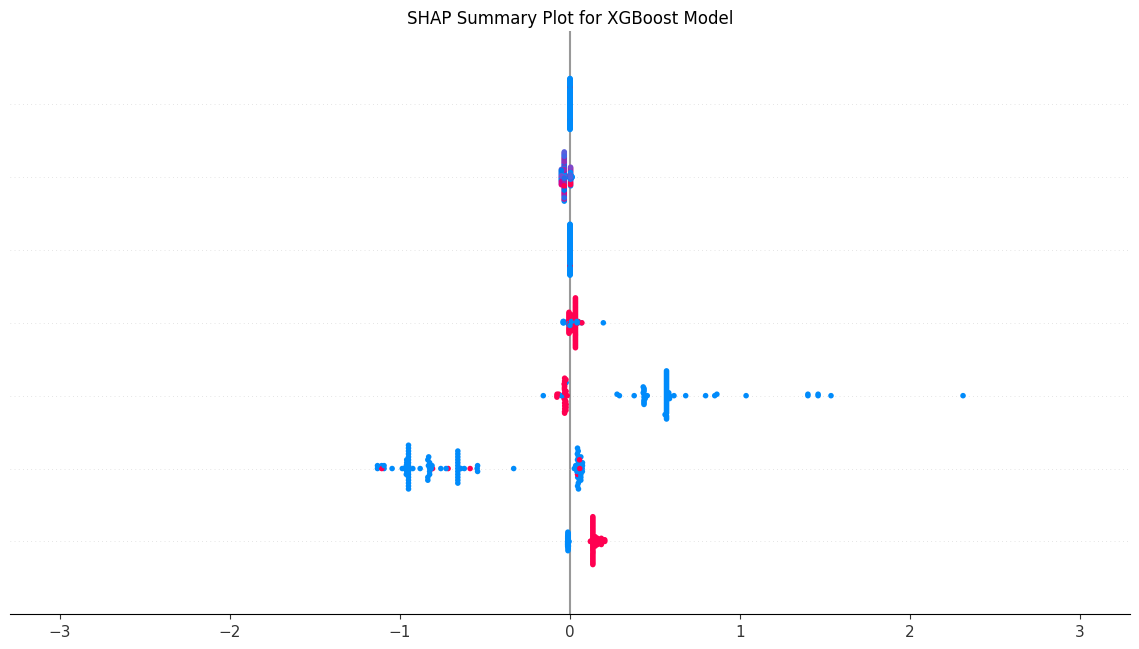

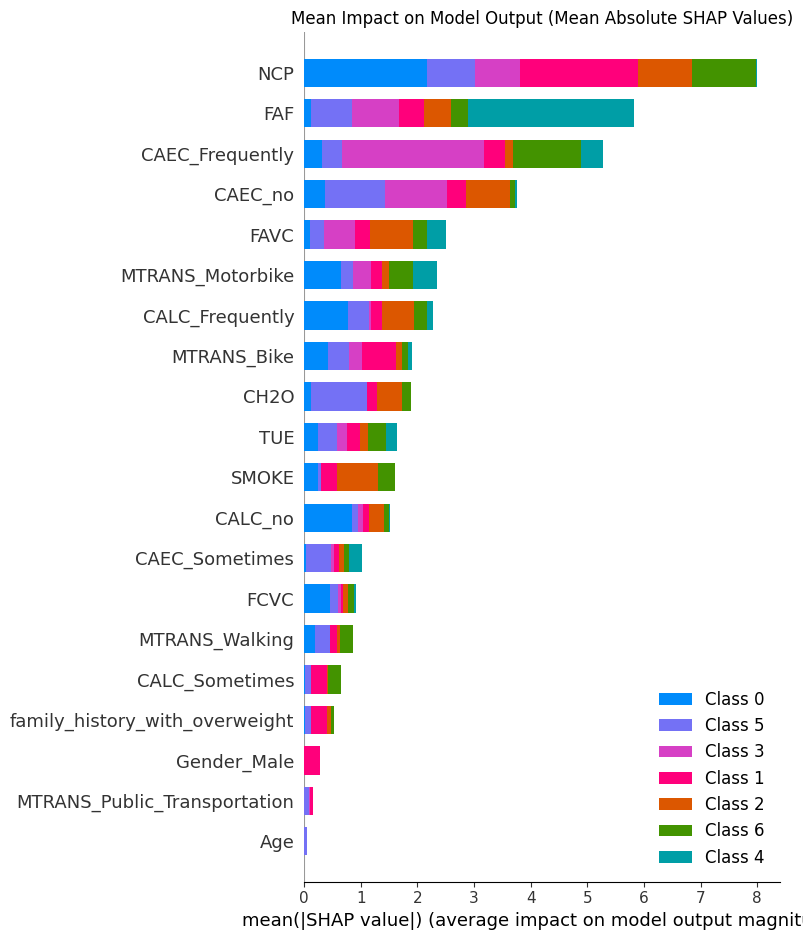

In [6]:
import shap

# Get the XGBoost model and sample data
xgb_model = RESULTS['real']['XGBoost']['fitted_model']

# Create a SHAP explainer for the model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for a subset of training data (100 samples for visualization)
shap_values = explainer.shap_values(X_train[:100])

# Create summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_train[:100], feature_names=X_train.columns, show=False)
plt.title('SHAP Summary Plot for XGBoost Model')
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_train[:100], feature_names=X_train.columns, plot_type="bar", show=False)
plt.title('Mean Impact on Model Output (Mean Absolute SHAP Values)')
plt.tight_layout()
plt.show()

In [82]:
import itertools

"""
conf_matrix:   [[50  1  0  0  0  5  0]
                [ 5 41  3  0  1  4  8]
                [ 0  8 59  6  0  2  3]
                [ 0  3  1 52  0  0  2]
                [ 0  0  0  0 63  0  0]
                [ 0 10  4  0  0 38  4]
                [ 0  3  3  8  1  3 32]]
"""
def plot_confusion_matrix(conf_matrix, classes, title, subtitle=None, cmap=plt.cm.Blues):
    plt.imshow(conf_matrix, interpolation='nearest', cmap=cmap)
    plt.title(title)
    if subtitle:
        plt.text(0.02, 0.02, subtitle, transform=plt.gca().transAxes, horizontalalignment='right')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')  # Added ha='right' for better alignment
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = conf_matrix.max() / 2.
    for i, j in itertools.product(range(conf_matrix.shape[0]), range(conf_matrix.shape[1])):
        plt.text(j, i, format(conf_matrix[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    # Add some padding to prevent label cutoff
    plt.subplots_adjust(bottom=0.15)
    plt.show()


Confusion Matrices for Real Dataset:

RandomForest Classifier:
[[52  2  0  0  0  2  0]
 [ 3 48  4  1  0  4  2]
 [ 0  7 67  3  0  1  0]
 [ 0  3  1 54  0  0  0]
 [ 0  0  0  0 63  0  0]
 [ 0 11  3  1  0 40  1]
 [ 0  3  4  2  0  2 39]]


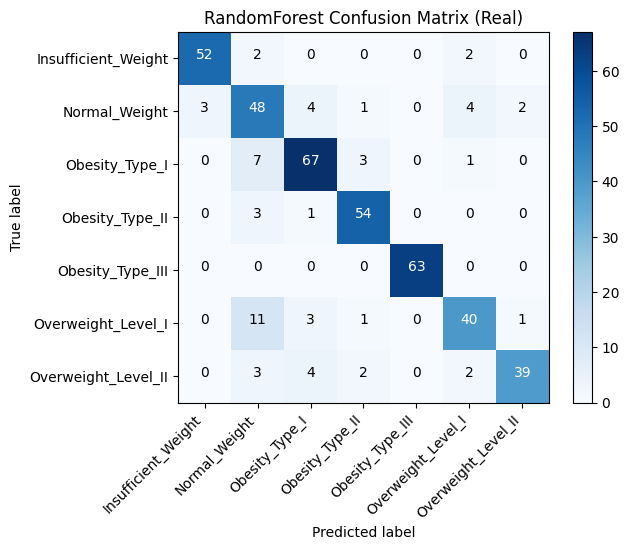


GradientBoosting Classifier:
[[50  1  0  0  0  5  0]
 [ 5 41  3  0  1  4  8]
 [ 0  8 59  6  0  2  3]
 [ 0  3  1 52  0  0  2]
 [ 0  0  0  0 63  0  0]
 [ 0 10  4  0  0 38  4]
 [ 0  3  3  8  1  3 32]]


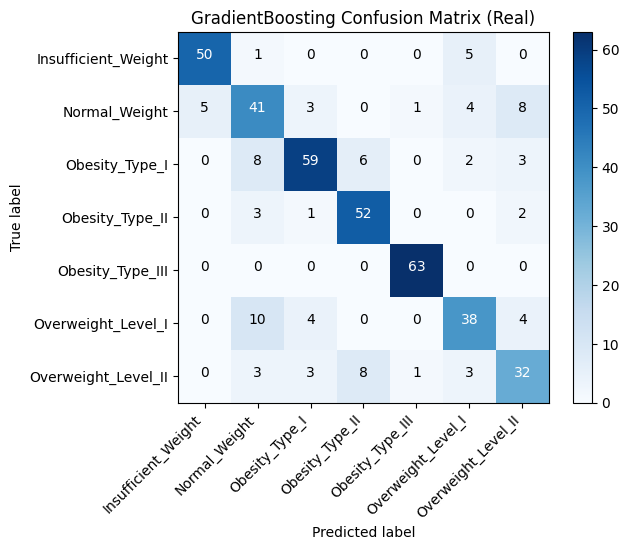


SVM Classifier:
[[49  3  0  0  0  4  0]
 [16 26  5  0  0  7  8]
 [ 2  3 53 13  2  2  3]
 [ 0  1  1 56  0  0  0]
 [ 0  0  0  0 63  0  0]
 [ 6  9 12  5  0 21  3]
 [ 0  4  8  8  1  4 25]]


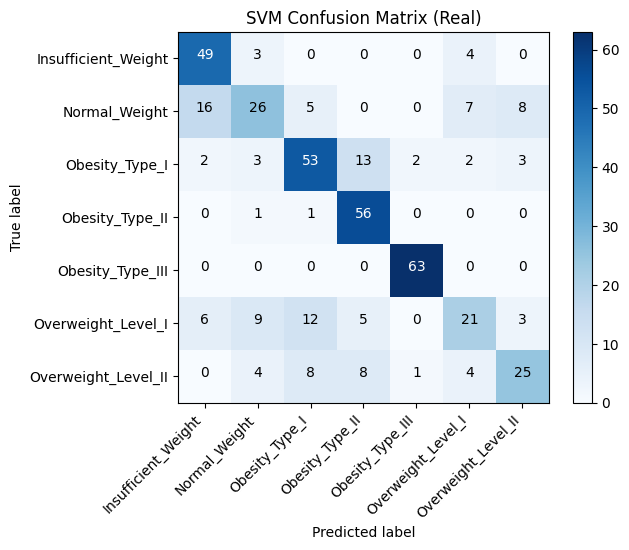


DecisionTree Classifier:
[[49  5  0  0  1  1  0]
 [ 7 33  4  2  2  7  7]
 [ 2  6 49  6  0  7  8]
 [ 0  1  0 53  0  2  2]
 [ 0  0  0  0 63  0  0]
 [ 2  6  4  1  0 36  7]
 [ 1  3  8  5  0  5 28]]


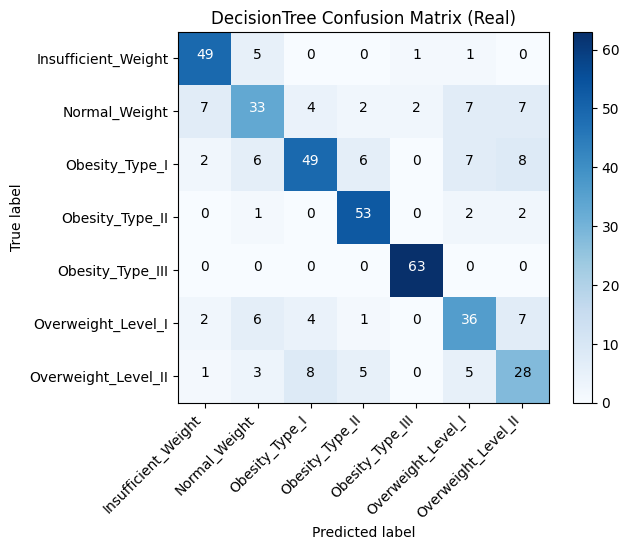


NaiveBayes Classifier:
[[42  0  3 10  0  1  0]
 [42  2  5  2  0  6  5]
 [ 4  1 38 32  0  1  2]
 [ 1  0  1 56  0  0  0]
 [ 0  0  0  0 63  0  0]
 [20  2 12 14  0  5  3]
 [16  0 13 18  0  0  3]]


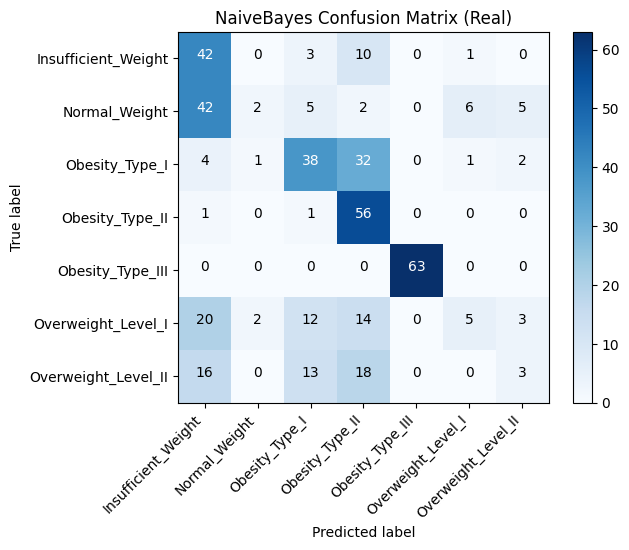


KNN Classifier:
[[50  1  2  0  0  3  0]
 [15 23 11  3  1  6  3]
 [ 2  0 65  4  1  2  4]
 [ 1  0  2 55  0  0  0]
 [ 0  0  0  0 63  0  0]
 [ 3  6  2  2  0 42  1]
 [ 1  1  5  4  2  2 35]]


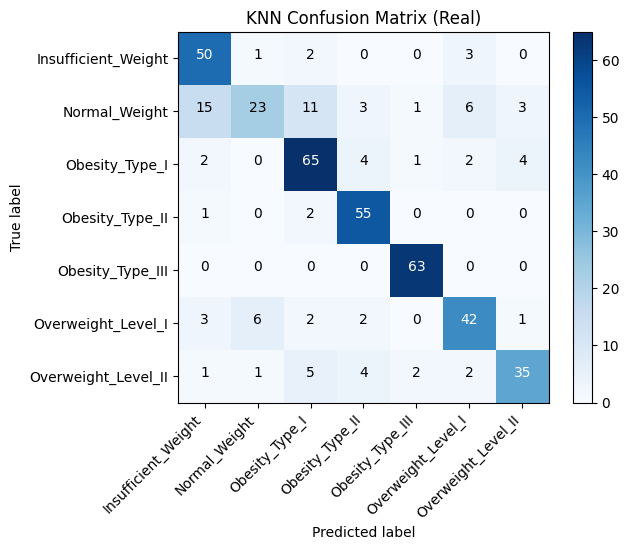


XGBoost Classifier:
[[51  1  0  0  0  4  0]
 [ 3 42  4  0  1  6  6]
 [ 1  6 66  4  0  1  0]
 [ 0  3  0 53  0  0  2]
 [ 0  0  0  0 63  0  0]
 [ 1  9  3  0  0 42  1]
 [ 1  1  7  5  1  3 32]]


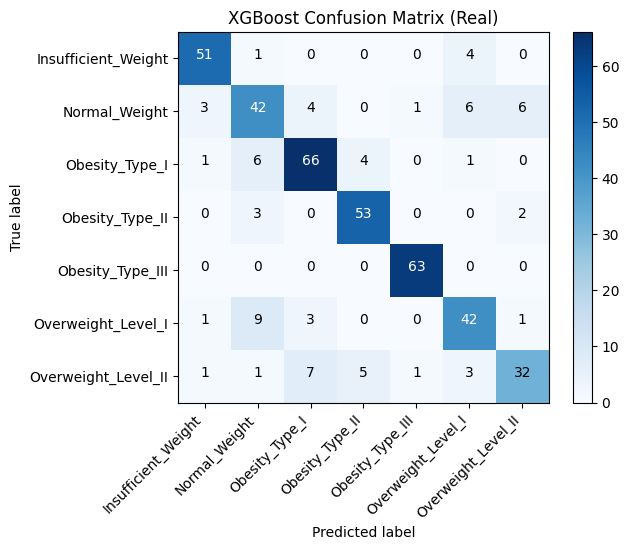


Confusion Matrices for Synthetic Dataset:

RandomForest Classifier:
[[52  0  0  0  0  4  0]
 [10 25  4  0  0 13 10]
 [ 2  6 56  6  0  2  6]
 [ 0  2  0 55  0  0  1]
 [ 0  0  0  0 63  0  0]
 [ 4  7  5  2  0 32  6]
 [ 2  4  7  7  0  7 23]]


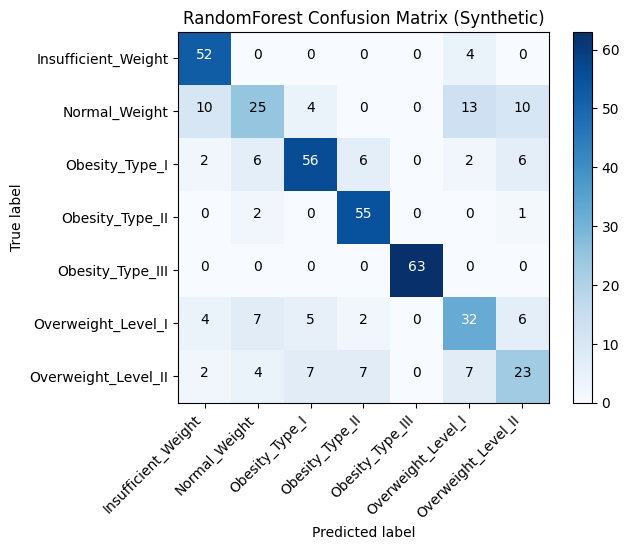


GradientBoosting Classifier:
[[52  0  1  0  0  3  0]
 [ 8 35  3  0  0  8  8]
 [ 5  5 53  8  0  2  5]
 [ 0  1  1 54  0  1  1]
 [ 0  0  0  0 63  0  0]
 [ 8  4  7  4  0 29  4]
 [ 1  1 10  8  0  2 28]]


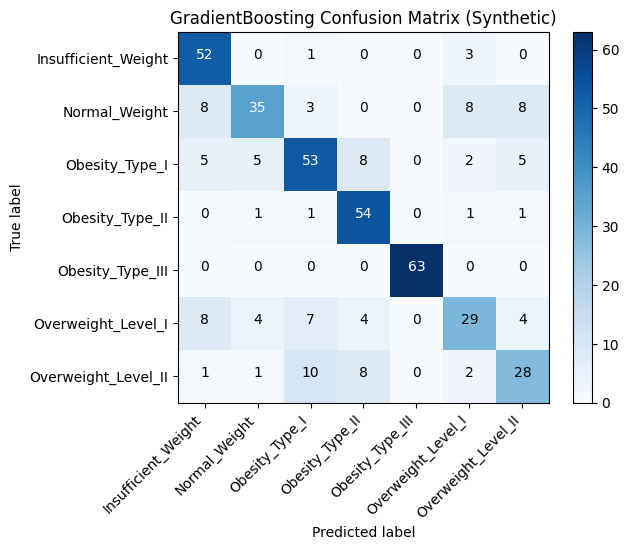


SVM Classifier:
[[48  2  1  0  0  5  0]
 [15 24  6  0  0  6 11]
 [ 1  4 50 12  1  3  7]
 [ 1  0  3 53  0  0  1]
 [ 0  0  0  0 63  0  0]
 [ 6 10  9  5  0 24  2]
 [ 0  4 11  7  1  2 25]]


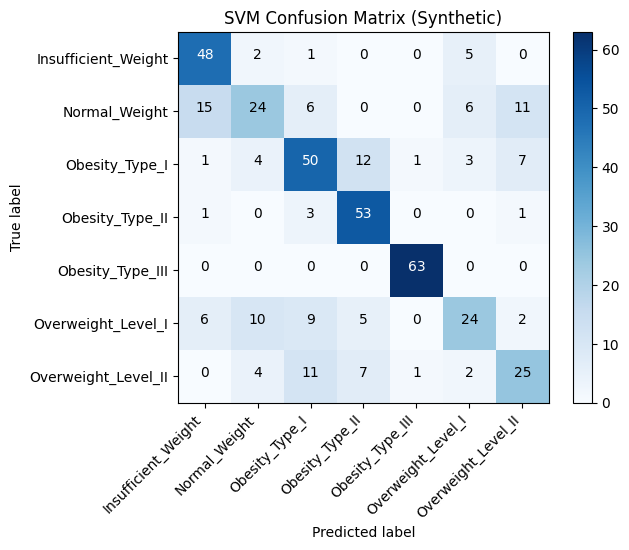


DecisionTree Classifier:
[[42  1  1  1  0  8  3]
 [11 12  4  2  0 18 15]
 [ 1  2 44  6  2  7 16]
 [ 0  2  4 50  0  1  1]
 [ 0  0  4  0 59  0  0]
 [ 5 10  9  6  0 16 10]
 [ 3  4  9  4  0  5 25]]


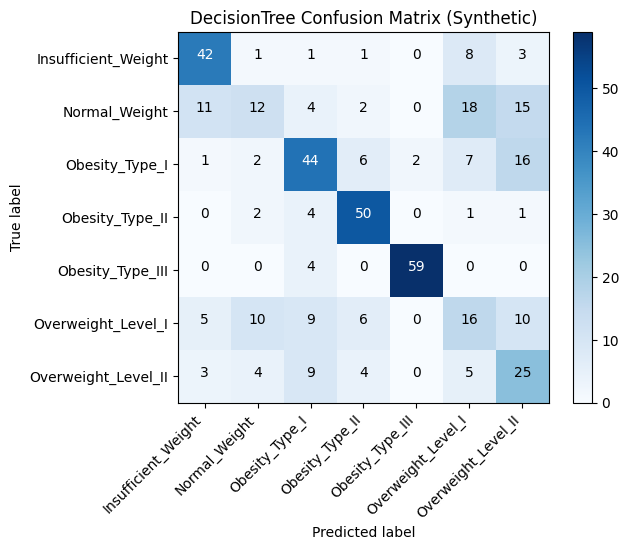


NaiveBayes Classifier:
[[42  0  2 11  0  1  0]
 [36 11  4  2  0  3  6]
 [ 3  1 33 36  0  1  4]
 [ 1  0  1 55  0  0  1]
 [ 0  0  0  0 63  0  0]
 [15  1 11 15  0  9  5]
 [ 4  1 10 21  0  0 14]]


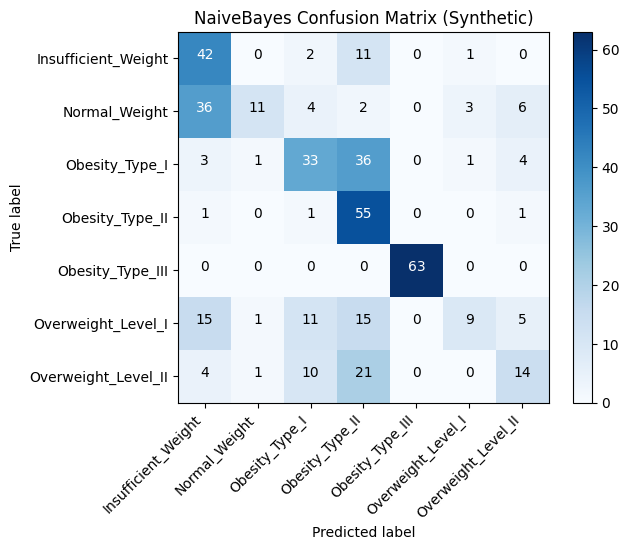


KNN Classifier:
[[50  1  1  1  0  3  0]
 [15 22 12  1  0  9  3]
 [ 2  6 55  7  1  1  6]
 [ 1  1  1 54  0  1  0]
 [ 0  0  0  0 63  0  0]
 [ 5 12  6  5  0 25  3]
 [ 1  5  8  8  1  7 20]]


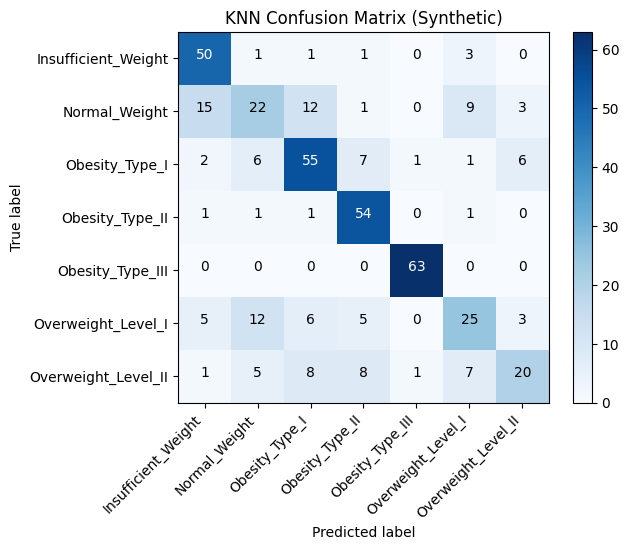


XGBoost Classifier:
[[52  0  0  0  0  4  0]
 [11 21  6  0  0 13 11]
 [ 3  3 56  7  0  4  5]
 [ 1  0  0 54  0  0  3]
 [ 0  0  0  0 63  0  0]
 [ 4  5  8  4  0 30  5]
 [ 0  1 10  6  0  4 29]]


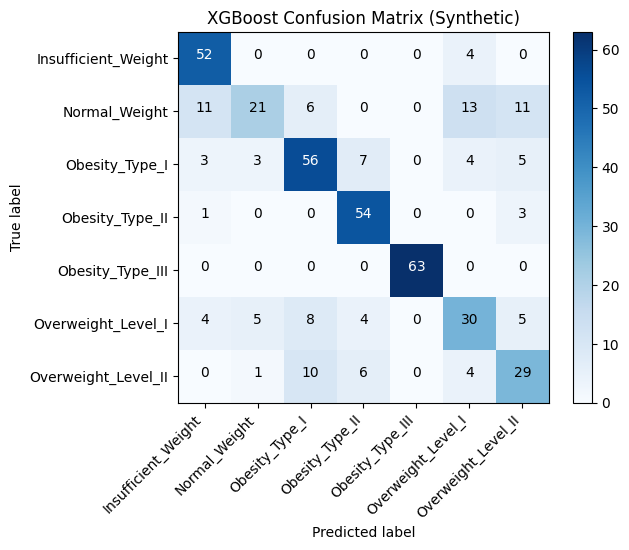


Confusion Matrices for Concatenated Dataset:

RandomForest Classifier:
[[52  2  0  0  0  2  0]
 [11 33  2  0  0  9  7]
 [ 1  5 60  6  0  1  5]
 [ 0  2  0 55  0  0  1]
 [ 0  0  0  0 63  0  0]
 [ 3  6  4  2  0 38  3]
 [ 1  3  4  6  0  5 31]]


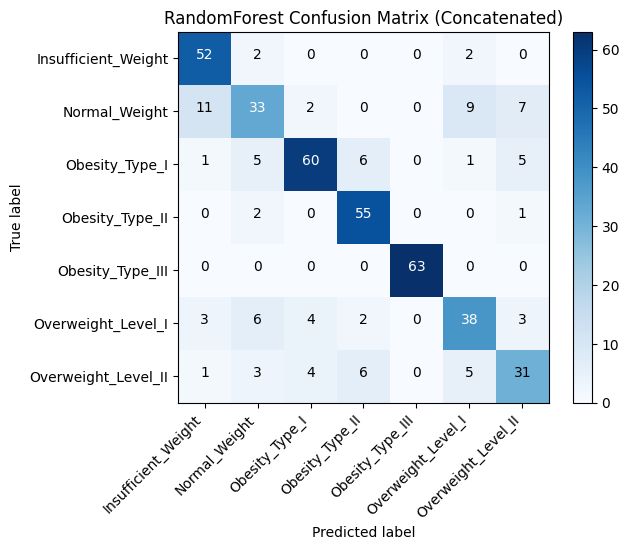


GradientBoosting Classifier:
[[51  2  0  0  0  3  0]
 [ 6 38  4  0  0  7  7]
 [ 3  7 58  6  0  1  3]
 [ 0  2  0 55  0  1  0]
 [ 0  0  0  0 63  0  0]
 [ 3  6  7  2  0 34  4]
 [ 2  1 10  9  0  3 25]]


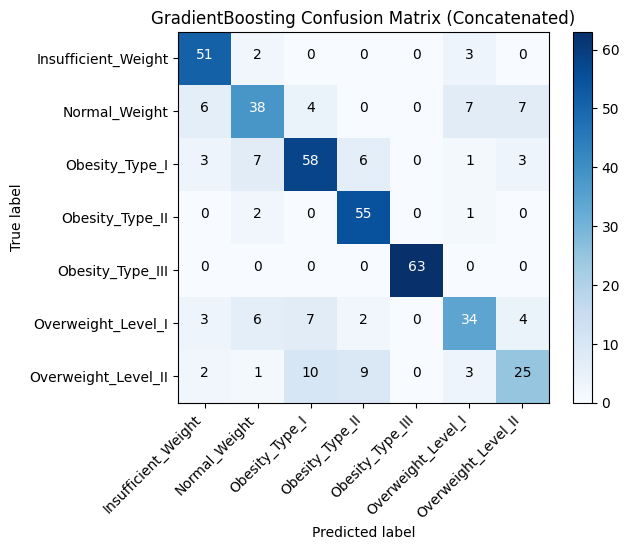


SVM Classifier:
[[49  2  1  0  0  4  0]
 [15 27  6  0  0  5  9]
 [ 1  4 53 12  1  2  5]
 [ 1  0  1 55  0  0  1]
 [ 0  0  0  0 63  0  0]
 [ 5  8  9  4  0 28  2]
 [ 1  3 10  8  1  2 25]]


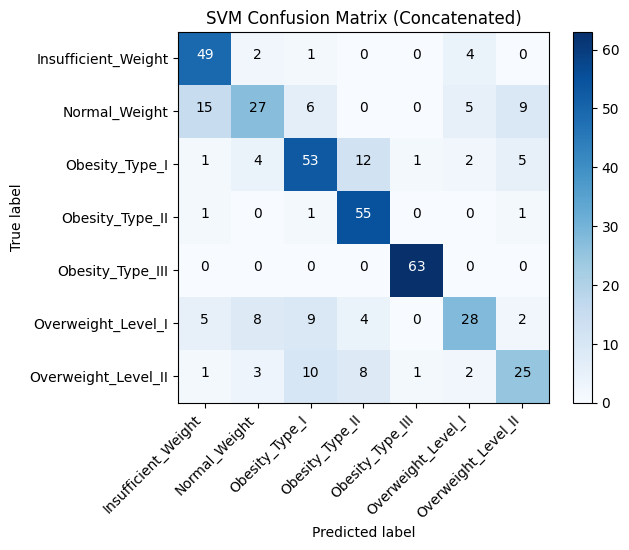


DecisionTree Classifier:
[[50  1  2  0  0  3  0]
 [10 15  5  1  0 16 15]
 [ 2  1 58  5  0  4  8]
 [ 1  1  0 52  0  1  3]
 [ 0  0  0  0 63  0  0]
 [ 2  6  8  1  0 32  7]
 [ 2  2  6  3  0  4 33]]


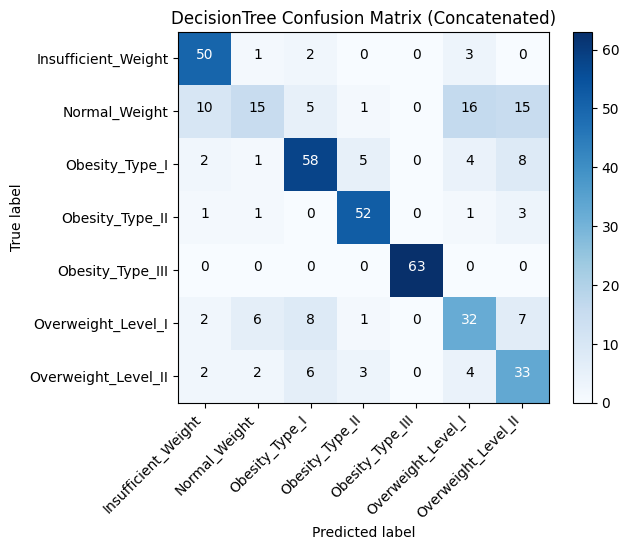


NaiveBayes Classifier:
[[42  0  2 11  0  1  0]
 [34  9  4  2  0  6  7]
 [ 3  1 32 35  0  1  6]
 [ 1  0  1 55  0  0  1]
 [ 0  0  0  0 63  0  0]
 [15  1 10 15  0  9  6]
 [ 6  1  8 21  0  1 13]]


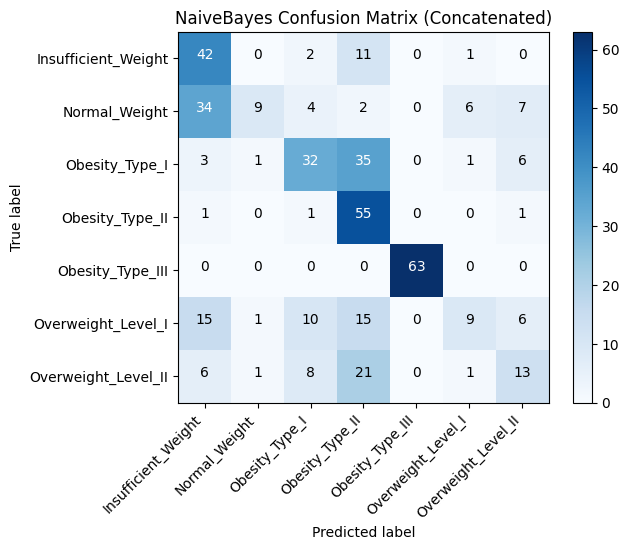


KNN Classifier:
[[50  1  1  0  0  4  0]
 [15 21 10  3  0 10  3]
 [ 1  5 61  6  1  1  3]
 [ 1  1  1 54  0  1  0]
 [ 0  0  0  0 63  0  0]
 [ 4 11  3  5  0 29  4]
 [ 0  3  4  7  1  4 31]]


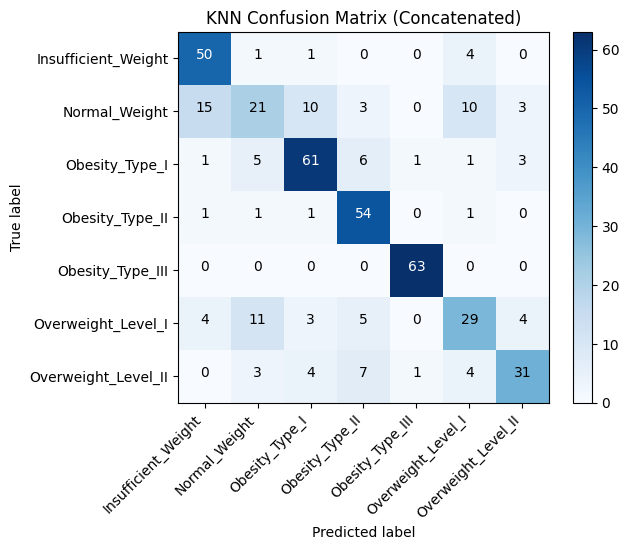


XGBoost Classifier:
[[52  0  1  0  0  3  0]
 [ 5 42  4  0  0  5  6]
 [ 2  7 62  6  0  0  1]
 [ 0  1  0 55  0  1  1]
 [ 0  0  0  0 63  0  0]
 [ 1  9  6  2  0 37  1]
 [ 0  2  8  6  1  4 29]]


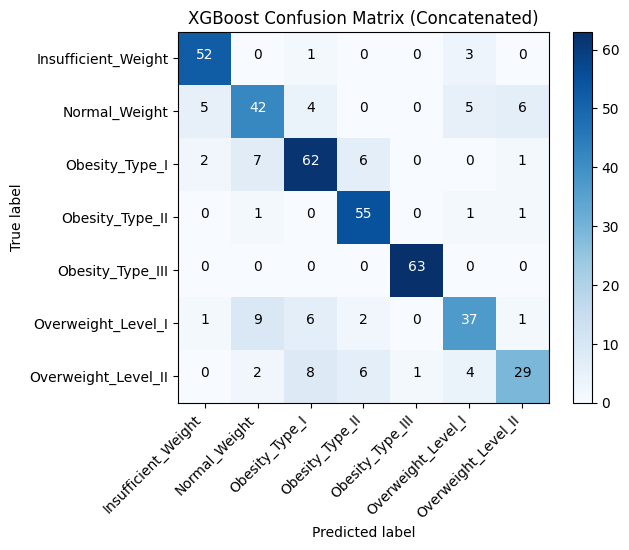

In [85]:
# Now let's do the other classifiers with proper label encoding
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder  # Add LabelEncoder

classifiers = {
    'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_jobs=-1)
}

# Initialize LabelEncoder
le = LabelEncoder()

# For each dataset
for dataset_name in DATASETS.keys():
    print(f"\nConfusion Matrices for {dataset_name.capitalize()} Dataset:")
    
    # Get the data for this dataset
    X_train = DATASETS[dataset_name]['X']['train']
    y_train = DATASETS[dataset_name]['y']['train']
    X_test = DATASETS[dataset_name]['X']['test']
    y_test = DATASETS[dataset_name]['y']['test']
    
    # Ensure we use the same column order for prediction
    common_columns = list(set(X_train.columns) & set(X_test.columns))
    X_test_filtered = X_test[common_columns]
    
    # Fit and transform the labels
    le.fit(y_train.values.ravel())
    y_test_encoded = le.transform(y_test.values.ravel())
    
    for name, data in RESULTS[dataset_name].items():
        clf = data['fitted_model']
        y_pred_encoded = clf.predict(X_test_filtered)
        # Transform predictions back to original labels
        y_pred = le.inverse_transform(y_pred_encoded)
        print(f"\n{name} Classifier:")
        conf_matrix = confusion_matrix(y_test_encoded, y_pred_encoded)
        print(conf_matrix)
        plot_confusion_matrix(conf_matrix, classes=le.classes_, title=f"{name} Confusion Matrix ({dataset_name.capitalize()})")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a441f35e-4b4c-4c50-b56a-1aea6b800ed8' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>